## Import necessary libraries and packages for preprocessing

In [2]:
import os
import mne
import joblib
import numpy as np
import os.path as op
import matplotlib.pyplot as plt
from mne.preprocessing import (ICA, corrmap, create_ecg_epochs, annotate_muscle_zscore, annotate_movement, 
                               compute_average_dev_head_t, create_eog_epochs, maxwell_filter, find_bad_channels_maxwell, 
                               maxwell_filter_prepare_emptyroom, find_eog_events, find_ecg_events)
from mne.chpi import (compute_chpi_amplitudes, compute_chpi_locs, compute_head_pos, write_head_pos)
#from mne.epochs import (average_movements)

## Load correct path to files and generate relative folders for outputs

In [5]:
# Set pathway and doucment location
s = 'p024'
v = 'Final'
path = f'/Users/siddarthchilukuri/Documents/IMM-Lab/Gabor_MEG/Prepro'
meg_dir = op.join(path, f'{s}_MEG_ENS_Gabor')

In [6]:
# Generate result folders
if not os.path.exists(op.join(meg_dir, v)):
    os.makedirs(op.join(meg_dir, v))

if not os.path.exists(op.join(meg_dir,v,'figures')):
    os.makedirs(op.join(meg_dir,v,'figures'))

if not os.path.exists(op.join(meg_dir,v,'Evoked')):
    os.makedirs(op.join(meg_dir,v,'Evoked'))

if not os.path.exists(op.join(meg_dir,v,'Source_Level')):
    os.makedirs(op.join(meg_dir,v,'Source_Level'))

In [7]:
# # read in all raw data 
# # please run the next cell
# raw1 = mne.io.Raw(op.join(meg_dir,f'{s}_MEG_ENS_Gabor_01_raw.fif'), preload=True)
# raw2 = mne.io.Raw(op.join(meg_dir,f'{s}_MEG_ENS_Gabor_02_raw.fif'), preload=True)
# raw3 = mne.io.Raw(op.join(meg_dir,f'{s}_meg_ens_Gabor_03_raw.fif'), preload=True)
# raw4 = mne.io.Raw(op.join(meg_dir,f'{s}_meg_ens_Gabor_04_raw.fif'), preload=True)

# total_times = raw1.times.max() + raw2.times.max() + raw3.times.max() + raw4.times.max()

# raw1.append([raw2, raw3, raw4]) # , raw4, raw5, raw6, raw7, raw8

# # save new combined raw file
# raw1.save(op.join(meg_dir,f'{s}_MEG_ENS_GABOR_raw.fif'), overwrite = True)

# del raw1, raw2, raw3, raw4

In [8]:
# Read in all raw MEG data (8 Blocks)
raw = mne.io.Raw(op.join(meg_dir, f'{s}_meg_ens_Gabor_01_raw.fif'), preload=True)
raw2 = mne.io.Raw(op.join(meg_dir,f'{s}_meg_ens_Gabor_02_raw.fif'), preload=True)
raw3 = mne.io.Raw(op.join(meg_dir,f'{s}_meg_ens_Gabor_03_raw.fif'), preload=True)
raw4 = mne.io.Raw(op.join(meg_dir,f'{s}_meg_ens_Gabor_04_raw.fif'), preload=True)
raw5 = mne.io.Raw(op.join(meg_dir,f'{s}_meg_ens_Gabor_05_raw.fif'), preload=True)
raw6 = mne.io.Raw(op.join(meg_dir,f'{s}_meg_ens_Gabor_06_raw.fif'), preload=True)
raw7 = mne.io.Raw(op.join(meg_dir,f'{s}_meg_ens_Gabor_07_raw.fif'), preload=True)
raw8 = mne.io.Raw(op.join(meg_dir,f'{s}_meg_ens_Gabor_08_raw.fif'), preload=True)

total_times = raw.times.max() + raw2.times.max() + raw3.times.max() + raw4.times.max() + raw5.times.max() + raw6.times.max() + raw7.times.max() + raw8.times.max()

raw.append([raw2, raw3, raw4, raw5, raw6, raw7, raw8])

# save new combined raw file
raw.save(op.join(meg_dir,f'{s}_MEG_ENS_GABOR_raw.fif'), overwrite = True)

del raw, raw2, raw3, raw4, raw5, raw6, raw7, raw8

Opening raw data file /Users/siddarthchilukuri/Documents/IMM-Lab/Gabor_MEG/Prepro/p024_MEG_ENS_Gabor/p024_meg_ens_Gabor_01_raw.fif...
    Read a total of 13 projection items:
        generated with dossp-2.1 (1 x 306)  idle
        generated with dossp-2.1 (1 x 306)  idle
        generated with dossp-2.1 (1 x 306)  idle
        generated with dossp-2.1 (1 x 306)  idle
        generated with dossp-2.1 (1 x 306)  idle
        generated with dossp-2.1 (1 x 306)  idle
        generated with dossp-2.1 (1 x 306)  idle
        generated with dossp-2.1 (1 x 306)  idle
        generated with dossp-2.1 (1 x 306)  idle
        generated with dossp-2.1 (1 x 306)  idle
        generated with dossp-2.1 (1 x 306)  idle
        generated with dossp-2.1 (1 x 306)  idle
        generated with dossp-2.1 (1 x 306)  idle
    Range : 9000 ... 403999 =      9.000 ...   403.999 secs
Ready.
Reading 0 ... 394999  =      0.000 ...   394.999 secs...
Opening raw data file /Users/siddarthchilukuri/Documents/IMM-Lab

: 

In [8]:
# Load empty room data
raw_erm = mne.io.read_raw_fif(op.join(meg_dir, f'{s}_meg_ens_Gabor_erm_raw.fif'), preload=True)

# Load raw experimental data
raw = mne.io.Raw(op.join(meg_dir,f'{s}_MEG_ENS_GABOR_raw.fif'), preload=True)

Opening raw data file C:/Users/csq2002.stu/Gabor_MEG/Prepro\p028_MEG_ENS_Gabor\p028_meg_ens_Gabor_erm_raw.fif...
    Read a total of 13 projection items:
        generated with dossp-2.1 (1 x 306)  idle
        generated with dossp-2.1 (1 x 306)  idle
        generated with dossp-2.1 (1 x 306)  idle
        generated with dossp-2.1 (1 x 306)  idle
        generated with dossp-2.1 (1 x 306)  idle
        generated with dossp-2.1 (1 x 306)  idle
        generated with dossp-2.1 (1 x 306)  idle
        generated with dossp-2.1 (1 x 306)  idle
        generated with dossp-2.1 (1 x 306)  idle
        generated with dossp-2.1 (1 x 306)  idle
        generated with dossp-2.1 (1 x 306)  idle
        generated with dossp-2.1 (1 x 306)  idle
        generated with dossp-2.1 (1 x 306)  idle
    Range : 3000 ... 340999 =      3.000 ...   340.999 secs
Ready.
Reading 0 ... 337999  =      0.000 ...   337.999 secs...
Opening raw data file C:/Users/csq2002.stu/Gabor_MEG/Prepro\p028_MEG_ENS_Gabor\p028_M

## Visualize MEG channels by interactive windows & Power Spectral Density

In [26]:
# Use this command to visualise interactive plot, "raw.info" will show some infromation 
%matplotlib qt
raw.copy().filter(l_freq=1, h_freq=80).plot(n_channels = 25)  # Change n_channels can adjust the size 

#record bad channels here, you will add them at a later step!!!!!!!!!
# Raw PSD Plot
fig1 = raw.compute_psd(fmin=1,fmax=100, n_fft=1000).plot()
fig1.suptitle('Raw PSD Plot')
plt.show()
fig1.savefig(op.join(meg_dir,v,'figures', f'{s}_GABOR_raw_psd'))
# Empty Room PSD Plot
fig2 = raw_erm.compute_psd(fmin=1,fmax=100, n_fft=1000).plot()
fig2.suptitle('Raw empty room PSD Plot')
plt.show()
fig2.savefig(op.join(meg_dir,v,'figures', f'{s}_GABOR_erm_raw_psd'))

Filtering raw data in 8 contiguous segments
Setting up band-pass filter from 1 - 80 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 1.00
- Lower transition bandwidth: 1.00 Hz (-6 dB cutoff frequency: 0.50 Hz)
- Upper passband edge: 80.00 Hz
- Upper transition bandwidth: 20.00 Hz (-6 dB cutoff frequency: 90.00 Hz)
- Filter length: 3301 samples (3.301 s)



[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.0s
[Parallel(n_jobs=1)]: Done  71 tasks      | elapsed:    0.4s
[Parallel(n_jobs=1)]: Done 161 tasks      | elapsed:    0.9s
[Parallel(n_jobs=1)]: Done 287 tasks      | elapsed:    1.7s


Effective window size : 1.000 (s)
Plotting power spectral density (dB=True).
Effective window size : 1.000 (s)
Plotting power spectral density (dB=True).


## Begin preprocessing here

In [18]:
# Set to True if headpos has not already been calculated & saved
calc_headpos =  False #True # 

# Other parameters
lpval = 1    # Low-frequency band is 1 Hz
hpval = 80   # High-frquency band is 80 Hz

# For kid, 6 and .98; For adults, 10 and .99/98
tsss_dur = 10
tsss_cor = .99

# read in system specific cross-talk and fine calibration files 
Crosstalk = op.join(path, 'ct_sparse.fif')
Fine_calibration = op.join(path, 'sss_cal.dat')

In [10]:
# Calculate data duration
raw_duration = raw.times[-1] 
print("duration of raw data:", raw_duration)
erm_duration = raw_erm.times[-1] 
print("duration of raw erm data:", erm_duration)

duration of raw data: 3175.999
duration of raw erm data: 337.999


In [11]:
# Crop data such that it is divisible by tsss_dur (10)
raw.crop(tmax=3170)
raw_erm.crop(tmax=330)

<Raw | p028_meg_ens_Gabor_erm_raw.fif, 320 x 330001 (330.0 s), ~806.5 MiB, data loaded>

In [12]:
#check if data has been cropped
raw_duration = raw.times[-1] 
print("duration of raw data:", raw_duration)
erm_duration = raw_erm.times[-1] 
print("duration of raw erm data:", erm_duration)

duration of raw data: 3170.0
duration of raw erm data: 330.0


## Compute time varying head position indicator (cHPI) amplitudes

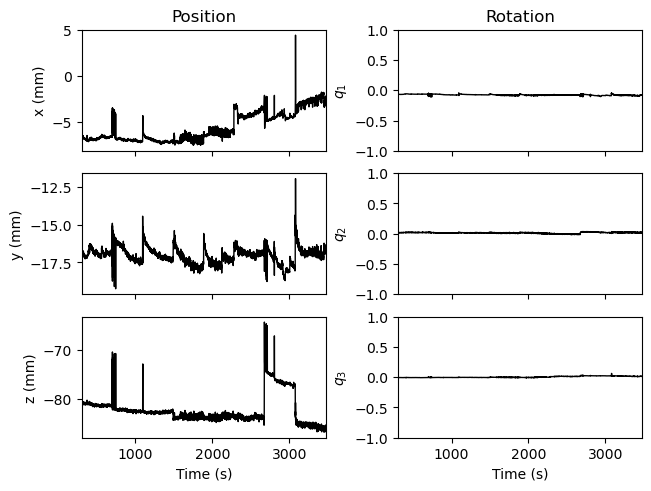

In [19]:
# setup for movement compensation by extracting coil info (perform on unfiltered raw)
if calc_headpos == True:
    amps = compute_chpi_amplitudes(raw)
    locs = compute_chpi_locs(raw.info, amps)
    pos = compute_head_pos(raw.info, locs, verbose = True)  #, gof_limit=0.9) 
    # save pos file (computing takes awhile)
    write_head_pos(op.join(meg_dir,v, f'{s}_GABOR_all_pos.fif'), pos)
else:
    pos = mne.chpi.read_head_pos(op.join(meg_dir,v, f'{s}_GABOR_all_pos.fif'))
    
# get initial head position and calculate average position (across time)
orig_head_dev_t = mne.transforms.invert_transform(raw.info["dev_head_t"])
avg_head_dev_t = mne.transforms.invert_transform(compute_average_dev_head_t (raw, pos))

fig = mne.viz.plot_head_positions(pos)
for ax, val, val_ori in zip(
    fig.axes[::2],
    avg_head_dev_t["trans"][:3, 3],
    orig_head_dev_t["trans"][:3, 3],
):
    ax.axhline(1000 * val, color="r")
    ax.axhline(1000 * val_ori, color="g")
fig.savefig(op.join(meg_dir,v,'figures', f'{s}_GABOR_all_headpos'))

# use average position for movement compensation destination    
destination = (raw.info['dev_head_t']['trans'][:3, 3]) # specifies which head file to use. 

## Remove power line noisy (60Hz), via Notch filter

In [10]:
# Filter out cHPI signals first
#raw_cHPI = raw.copy()
#mne.chpi.filter_chpi(raw_cHPI) 

# Remove power line noise (60 Hz for US and Canada)
raw_Notch = raw.copy()
raw_erm_Notch = raw_erm.copy()
raw_Notch.notch_filter(freqs = 60, fir_design='firwin')   #mt_bandwidth = 4  method='spectrum_fit',
raw_erm_Notch.notch_filter(freqs = 60, fir_design='firwin')  # mt_bandwidth = 4,  method='spectrum_fit',

# We will use Notch filtered data next, delete previous data to save storage
del raw, raw_erm

# Visualize the power spectral density 
EMM = raw_Notch.compute_psd(fmin=1, fmax=90, n_fft=1000, picks='meg').plot()
EMM.suptitle('Raw Notch (60Hz) only, no eSSS')
EMM.savefig(op.join(meg_dir,v,'figures', f'{s}_Raw_Notch_Filtered_60Hz'))

EMMMM = raw_erm_Notch.compute_psd(fmin=1, fmax=90, n_fft=1000, picks='meg').plot()
EMMMM.suptitle('Empty Room Notch (60Hz) only, no eSSS')
EMMMM.savefig(op.join(meg_dir,v,'figures', f'{s}_Raw_Empty_Room_Notch_Filtered_60Hz'))

Filtering raw data in 8 contiguous segments
Setting up band-stop filter from 59 - 61 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandstop filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 59.35
- Lower transition bandwidth: 0.50 Hz (-6 dB cutoff frequency: 59.10 Hz)
- Upper passband edge: 60.65 Hz
- Upper transition bandwidth: 0.50 Hz (-6 dB cutoff frequency: 60.90 Hz)
- Filter length: 6601 samples (6.601 s)



[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.0s
[Parallel(n_jobs=1)]: Done  71 tasks      | elapsed:    0.4s
[Parallel(n_jobs=1)]: Done 161 tasks      | elapsed:    1.0s


Setting up band-stop filter from 59 - 61 Hz


[Parallel(n_jobs=1)]: Done 287 tasks      | elapsed:    1.9s



FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandstop filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 59.35
- Lower transition bandwidth: 0.50 Hz (-6 dB cutoff frequency: 59.10 Hz)
- Upper passband edge: 60.65 Hz
- Upper transition bandwidth: 0.50 Hz (-6 dB cutoff frequency: 60.90 Hz)
- Filter length: 6601 samples (6.601 s)



...

Filtering raw data in 1 contiguous segment


[Parallel(n_jobs=1)]: Done 287 tasks      | elapsed:    1.6s


Setting up band-stop filter from 59 - 61 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandstop filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 59.35
- Lower transition bandwidth: 0.50 Hz (-6 dB cutoff frequency: 59.10 Hz)
- Upper passband edge: 60.65 Hz
- Upper transition bandwidth: 0.50 Hz (-6 dB cutoff frequency: 60.90 Hz)
- Filter length: 6601 samples (6.601 s)



[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.0s
[Parallel(n_jobs=1)]: Done  71 tasks      | elapsed:    0.3s
[Parallel(n_jobs=1)]: Done 161 tasks      | elapsed:    0.8s
[Parallel(n_jobs=1)]: Done 287 tasks      | elapsed:    1.4s


Effective window size : 1.000 (s)
Plotting power spectral density (dB=True).
Effective window size : 1.000 (s)
Plotting power spectral density (dB=True).


In [ ]:
# Just in case, if you cannot finish entire perprocessing once. 
#raw_Notch.save(op.join(meg_dir,f'{s}_Raw_Notch_raw.fif'),overwrite = True)
#raw_erm_Notch.save(op.join(meg_dir,f'{s}_Raw_Empty_Notch_raw.fif'),overwrite = True)

# Read raw nothced files
# raw_Notch = mne.io.read_raw_fif(op.join(meg_dir, f'{s}_Raw_Notch_raw.fif'), preload=True)
# raw_erm_Notch = mne.io.read_raw_fif(op.join(meg_dir, f'{s}_Raw_Empty_Notch_raw.fif'), preload=True)

## Bad Channels Detection

Applying low-pass filter with 80 Hz cutoff frequency ...
Filtering raw data in 8 contiguous segments
Setting up low-pass filter at 80 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal lowpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Upper passband edge: 80.00 Hz
- Upper transition bandwidth: 20.00 Hz (-6 dB cutoff frequency: 90.00 Hz)
- Filter length: 165 samples (0.165 s)



[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.1s
[Parallel(n_jobs=1)]: Done  71 tasks      | elapsed:    0.6s
[Parallel(n_jobs=1)]: Done 161 tasks      | elapsed:    1.5s
[Parallel(n_jobs=1)]: Done 287 tasks      | elapsed:    2.7s


Scanning for bad channels in 638 intervals (5.0 s) ...
102 of 102 magnetometer types replaced with T3.
    No bad MEG channels
    Processing 204 gradiometers and 102 magnetometers
    Using fine calibration sss_cal.dat
        Adjusting non-orthogonal EX and EY
        Adjusted coil orientations by (μ ± σ): 0.4° ± 0.3° (max: 1.4°)
    Automatic origin fit: head of radius 82.3 mm
    Using origin 0.2, 5.1, 48.8 mm in the head frame
        Interval   1:    0.000 -    4.999
        Interval   2:    5.000 -    9.999
        Interval   3:   10.000 -   14.999
        Interval   4:   15.000 -   19.999
        Interval   5:   20.000 -   24.999
        Interval   6:   25.000 -   29.999
        Interval   7:   30.000 -   34.999
        Interval   8:   35.000 -   39.999
        Interval   9:   40.000 -   44.999
        Interval  10:   45.000 -   49.999
        Interval  11:   50.000 -   54.999
        Interval  12:   55.000 -   59.999
        Interval  13:   60.000 -   64.999
        Interval  

[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.0s
[Parallel(n_jobs=1)]: Done  71 tasks      | elapsed:    0.4s
[Parallel(n_jobs=1)]: Done 161 tasks      | elapsed:    1.0s
[Parallel(n_jobs=1)]: Done 287 tasks      | elapsed:    1.8s


Using matplotlib as 2D backend.


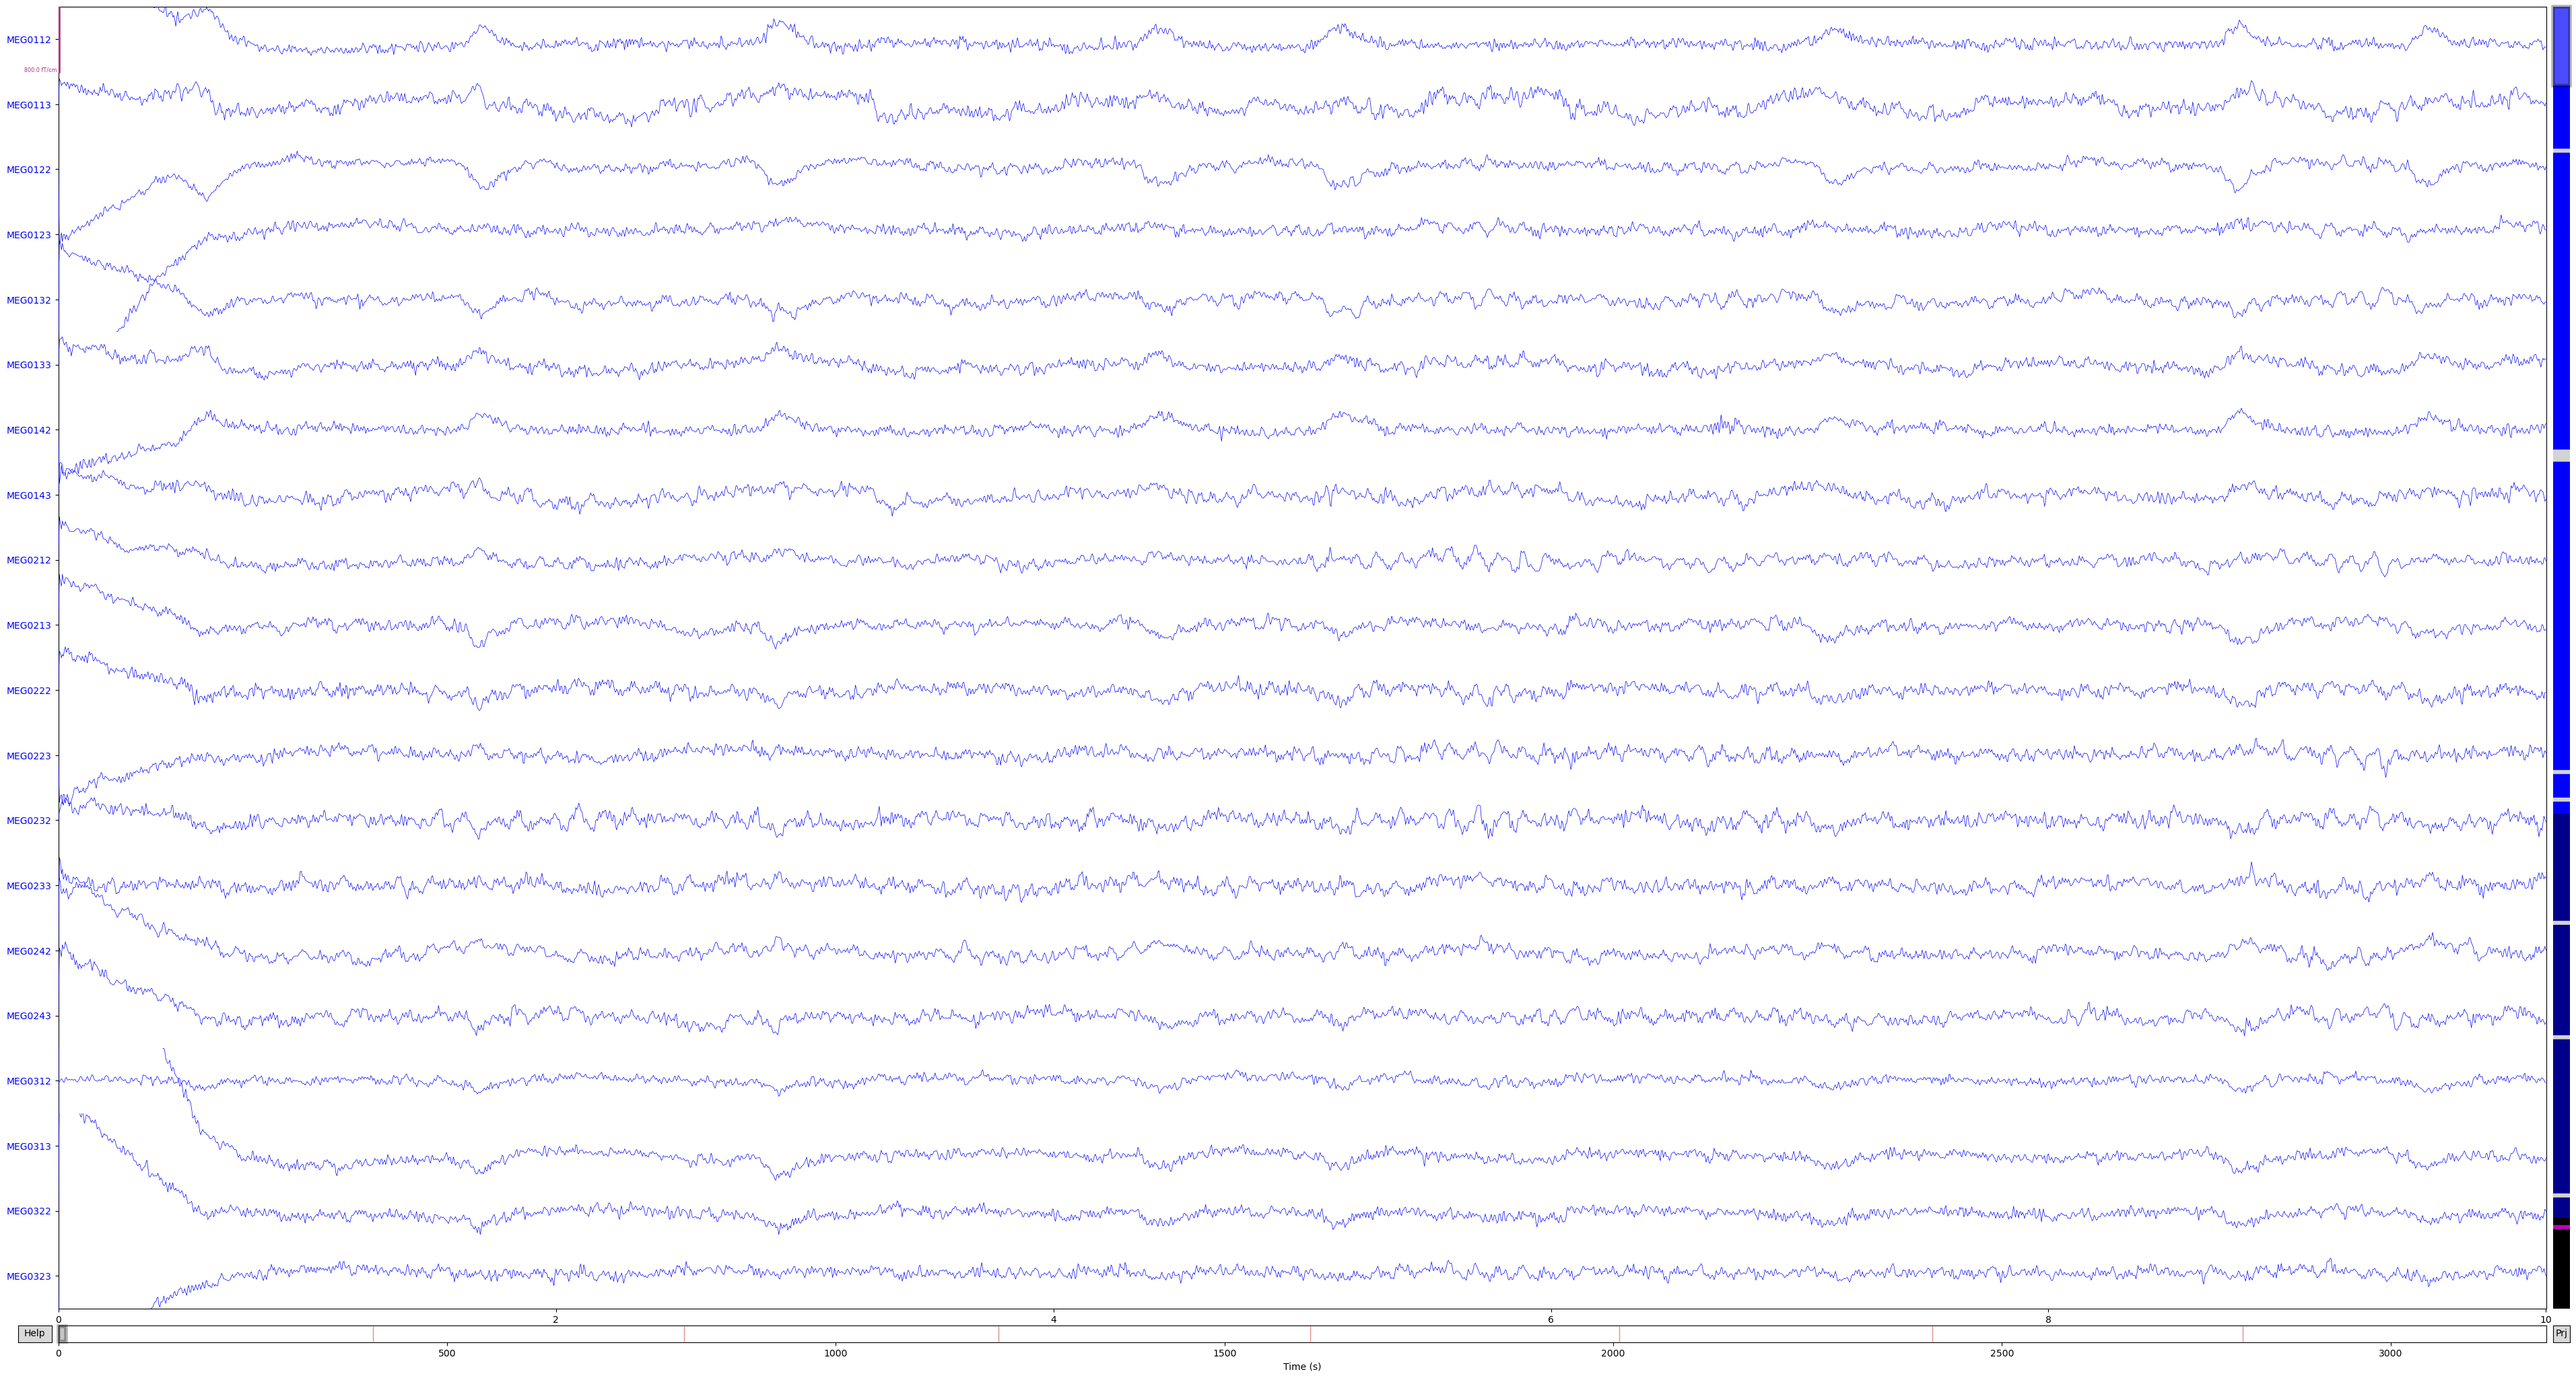

Channels marked as bad:
['MEG0532', 'MEG0741', 'MEG1531', 'MEG1532', 'MEG1533', 'MEG1542', 'MEG2531', 'MEG2533', 'MEG2632']


In [11]:
# Bad channel detection, Automated bad channels detector
raw_Notch.info['bads'] = []
raw_check = raw_Notch.copy()
auto_noisy_chs, auto_flat_chs, auto_scores = find_bad_channels_maxwell(raw_check, cross_talk = Crosstalk, calibration = Fine_calibration,
                                                                       head_pos=pos, return_scores=True, verbose=True, h_freq = hpval) # Change to 80 for now
#auto_noisy_chs: Automatically Detected Noisy Channels
# auto_flat_chs: Automatically Detected Flat Channels
# auto_scores: Detailed Channel Quality Scores)

# Combine all bad channels
bads = raw_check.info['bads'] + auto_noisy_chs + auto_flat_chs
raw_Notch.info['bads'] = bads

# Print the results (All bad channels)
print("noisy channels: ", ' '.join(auto_noisy_chs))
print("Flat channels: ", ' '.join(auto_flat_chs))
print("All bad channels: ", ' '.join(bads))

# Visualize bad channels, depends on you
raw_chan = raw_Notch.copy().filter(l_freq=lpval, h_freq=hpval, fir_design='firwin', phase='zero')
raw_chan.plot()

In [12]:
# Add bad channels here, normal bad channels and BAD CHANNELS HERE AFTER VISUAL INSPECTION TOO
All_Bad_Channels = raw_Notch.info['bads'] + ['MEG0932', 'MEG1132', 'MEG1213', 'MEG1933', 'MEG2122', 'MEG2142', 'MEG2143', 'MEG2213'] 
raw_Notch.info['bads'] = All_Bad_Channels
raw_erm_Notch.info['bads'] = raw_Notch.info['bads']

#check if all bads have been added
print(raw_Notch.info['bads'])
print(raw_erm_Notch.info['bads'])

['MEG0532', 'MEG0741', 'MEG1531', 'MEG1532', 'MEG1533', 'MEG1542', 'MEG2531', 'MEG2533', 'MEG2632', 'MEG0932', 'MEG1132', 'MEG1213', 'MEG1933', 'MEG2122', 'MEG2142', 'MEG2143', 'MEG2213']
['MEG0532', 'MEG0741', 'MEG1531', 'MEG1532', 'MEG1533', 'MEG1542', 'MEG2531', 'MEG2533', 'MEG2632', 'MEG0932', 'MEG1132', 'MEG1213', 'MEG1933', 'MEG2122', 'MEG2142', 'MEG2143', 'MEG2213']


In [13]:
# Band-pass Filter on both Raw and empty room data
raw_filtered = raw_Notch.copy().filter(l_freq=lpval, h_freq=hpval,fir_design='firwin',phase='zero') 
erm_filtered = raw_erm_Notch.copy().filter(l_freq=lpval, h_freq=hpval,fir_design='firwin',phase='zero') 

#check if all bads have been added in filtered as well
print(raw_filtered.info['bads'])
print(erm_filtered.info['bads'])

Filtering raw data in 8 contiguous segments
Setting up band-pass filter from 1 - 80 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 1.00
- Lower transition bandwidth: 1.00 Hz (-6 dB cutoff frequency: 0.50 Hz)
- Upper passband edge: 80.00 Hz
- Upper transition bandwidth: 20.00 Hz (-6 dB cutoff frequency: 90.00 Hz)
- Filter length: 3301 samples (3.301 s)



[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.0s
[Parallel(n_jobs=1)]: Done  71 tasks      | elapsed:    0.3s
[Parallel(n_jobs=1)]: Done 161 tasks      | elapsed:    0.9s
[Parallel(n_jobs=1)]: Done 287 tasks      | elapsed:    1.7s


Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 1 - 80 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 1.00
- Lower transition bandwidth: 1.00 Hz (-6 dB cutoff frequency: 0.50 Hz)
- Upper passband edge: 80.00 Hz
- Upper transition bandwidth: 20.00 Hz (-6 dB cutoff frequency: 90.00 Hz)
- Filter length: 3301 samples (3.301 s)



[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.0s
[Parallel(n_jobs=1)]: Done  71 tasks      | elapsed:    0.2s
[Parallel(n_jobs=1)]: Done 161 tasks      | elapsed:    0.7s


['MEG0532', 'MEG0741', 'MEG1531', 'MEG1532', 'MEG1533', 'MEG1542', 'MEG2531', 'MEG2533', 'MEG2632', 'MEG0932', 'MEG1132', 'MEG1213', 'MEG1933', 'MEG2122', 'MEG2142', 'MEG2143', 'MEG2213']
['MEG0532', 'MEG0741', 'MEG1531', 'MEG1532', 'MEG1533', 'MEG1542', 'MEG2531', 'MEG2533', 'MEG2632', 'MEG0932', 'MEG1132', 'MEG1213', 'MEG1933', 'MEG2122', 'MEG2142', 'MEG2143', 'MEG2213']


[Parallel(n_jobs=1)]: Done 287 tasks      | elapsed:    1.3s


In [ ]:
# Double Check the projectors
Filtered = erm_filtered.compute_psd(fmin=1, fmax=90, n_fft=1000, picks='meg').plot()
Filtered.suptitle('Filtered Empty Room Data from Projectors')

In [14]:
#find freq ranges to use for projections
erm1 = raw_erm_Notch.copy().filter(l_freq=8, h_freq=9)
erm2 = raw_erm_Notch.copy().filter(l_freq=21, h_freq=22)
erm3 = raw_erm_Notch.copy().filter(l_freq=29, h_freq=30)
erm4 = raw_erm_Notch.copy().filter(l_freq=42, h_freq=44)
erm5 = raw_erm_Notch.copy().filter(l_freq=50, h_freq=51) # Including power_line noisy. 
erm6 = raw_erm_Notch.copy().filter(l_freq=57, h_freq=59)
erm7 = raw_erm_Notch.copy().filter(l_freq=65, h_freq=67)

Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 8 - 9 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 8.00
- Lower transition bandwidth: 2.00 Hz (-6 dB cutoff frequency: 7.00 Hz)
- Upper passband edge: 9.00 Hz
- Upper transition bandwidth: 2.25 Hz (-6 dB cutoff frequency: 10.12 Hz)
- Filter length: 1651 samples (1.651 s)



[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.0s
[Parallel(n_jobs=1)]: Done  71 tasks      | elapsed:    0.2s
[Parallel(n_jobs=1)]: Done 161 tasks      | elapsed:    0.6s
[Parallel(n_jobs=1)]: Done 287 tasks      | elapsed:    1.2s


Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 21 - 22 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 21.00
- Lower transition bandwidth: 5.25 Hz (-6 dB cutoff frequency: 18.38 Hz)
- Upper passband edge: 22.00 Hz
- Upper transition bandwidth: 5.50 Hz (-6 dB cutoff frequency: 24.75 Hz)
- Filter length: 629 samples (0.629 s)



[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.0s
[Parallel(n_jobs=1)]: Done  71 tasks      | elapsed:    0.3s
[Parallel(n_jobs=1)]: Done 161 tasks      | elapsed:    0.7s
[Parallel(n_jobs=1)]: Done 287 tasks      | elapsed:    1.4s


Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 29 - 30 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 29.00
- Lower transition bandwidth: 7.25 Hz (-6 dB cutoff frequency: 25.38 Hz)
- Upper passband edge: 30.00 Hz
- Upper transition bandwidth: 7.50 Hz (-6 dB cutoff frequency: 33.75 Hz)
- Filter length: 457 samples (0.457 s)



...

[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.0s
[Parallel(n_jobs=1)]: Done  71 tasks      | elapsed:    0.3s
[Parallel(n_jobs=1)]: Done 161 tasks      | elapsed:    0.9s
[Parallel(n_jobs=1)]: Done 287 tasks      | elapsed:    1.6s


Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 57 - 59 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 57.00
- Lower transition bandwidth: 14.25 Hz (-6 dB cutoff frequency: 49.88 Hz)
- Upper passband edge: 59.00 Hz
- Upper transition bandwidth: 14.75 Hz (-6 dB cutoff frequency: 66.38 Hz)
- Filter length: 233 samples (0.233 s)



[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.0s
[Parallel(n_jobs=1)]: Done  71 tasks      | elapsed:    0.3s
[Parallel(n_jobs=1)]: Done 161 tasks      | elapsed:    0.8s
[Parallel(n_jobs=1)]: Done 287 tasks      | elapsed:    1.6s


Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 65 - 67 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 65.00
- Lower transition bandwidth: 16.25 Hz (-6 dB cutoff frequency: 56.88 Hz)
- Upper passband edge: 67.00 Hz
- Upper transition bandwidth: 16.75 Hz (-6 dB cutoff frequency: 75.38 Hz)
- Filter length: 205 samples (0.205 s)



[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.0s
[Parallel(n_jobs=1)]: Done  71 tasks      | elapsed:    0.3s
[Parallel(n_jobs=1)]: Done 161 tasks      | elapsed:    0.8s
[Parallel(n_jobs=1)]: Done 287 tasks      | elapsed:    1.5s


In [15]:
# Here we will bandapss the empty-room data around the vibration artifacts, compute erm projectors from empty-room to use for eSSS
erm_proj1 = mne.compute_proj_raw(erm1, meg='combined')
erm_proj2 = mne.compute_proj_raw(erm2, meg='combined')
erm_proj3 = mne.compute_proj_raw(erm3, meg='combined')
erm_proj4 = mne.compute_proj_raw(erm4, meg='combined')
erm_proj5 = mne.compute_proj_raw(erm5, meg='combined')
erm_proj6 = mne.compute_proj_raw(erm6, meg='combined')
erm_proj7 = mne.compute_proj_raw(erm7, meg='combined')

erm_projectors = erm_proj1 + erm_proj2 + erm_proj3 + erm_proj4 + erm_proj5 + erm_proj6 + erm_proj7
  
# print("all bad channels: " + ' '.join(raw_Notch.info['bads']))
# print("empty room bad channels: " + ' '.join(raw_erm.info['bads']))

# Plot the combined projectors
Projection_figure = mne.viz.plot_projs_topomap(erm_projectors, colorbar=True, info=raw_filtered.info)
Projection_figure.savefig(op.join(meg_dir,v,'figures', f'{s}_Projection_topography'))

# Prepare empty room for Maxwell filtering
erm_maxwell_prepare = maxwell_filter_prepare_emptyroom(erm_filtered, raw=raw_filtered)

Not setting metadata
320 matching events found
No baseline correction applied
Created an SSP operator (subspace dimension = 13)


[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.0s
[Parallel(n_jobs=1)]: Done  71 tasks      | elapsed:    0.0s
[Parallel(n_jobs=1)]: Done 161 tasks      | elapsed:    0.1s


Dropped 0/320 epochs
Adding projection: meg-Raw-0.000-320.001-PCA-01 (exp var=2.2%)
Adding projection: meg-Raw-0.000-320.001-PCA-02 (exp var=1.8%)
No channels 'eeg' found. Skipping.
Not setting metadata
320 matching events found
No baseline correction applied
Created an SSP operator (subspace dimension = 13)


[Parallel(n_jobs=1)]: Done 287 tasks      | elapsed:    0.2s
[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.0s
[Parallel(n_jobs=1)]: Done  71 tasks      | elapsed:    0.0s


Dropped 0/320 epochs


...

[Parallel(n_jobs=1)]: Done 161 tasks      | elapsed:    0.1s
[Parallel(n_jobs=1)]: Done 287 tasks      | elapsed:    0.2s


Adding projection: meg-Raw-0.000-320.001-PCA-02 (exp var=4.9%)
No channels 'eeg' found. Skipping.
Not setting metadata
320 matching events found
No baseline correction applied
Created an SSP operator (subspace dimension = 13)


[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.0s
[Parallel(n_jobs=1)]: Done  71 tasks      | elapsed:    0.0s
[Parallel(n_jobs=1)]: Done 161 tasks      | elapsed:    0.1s


Dropped 0/320 epochs
Adding projection: meg-Raw-0.000-320.001-PCA-01 (exp var=2.6%)
Adding projection: meg-Raw-0.000-320.001-PCA-02 (exp var=1.1%)
No channels 'eeg' found. Skipping.


[Parallel(n_jobs=1)]: Done 287 tasks      | elapsed:    0.2s


## Signal-Space Separation

In [17]:
# perform eSSS on filtered data
raw_esss = maxwell_filter(raw_filtered, calibration=Fine_calibration, cross_talk=Crosstalk, st_duration=10, bad_condition="ignore", extended_proj=erm_projectors, st_correlation=0.99, head_pos=pos, destination=destination, verbose=True)

erm_esss = maxwell_filter(erm_maxwell_prepare, calibration=Fine_calibration, cross_talk=Crosstalk, st_duration=10, extended_proj=erm_projectors, st_correlation=0.99, coord_frame="meg", verbose=True)

Maxwell filtering raw data
102 of 102 magnetometer types replaced with T3.
    Bad MEG channels being reconstructed: ['MEG0532', 'MEG0741', 'MEG1531', 'MEG1532', 'MEG1533', 'MEG1542', 'MEG2531', 'MEG2533', 'MEG2632', 'MEG0932', 'MEG1132', 'MEG1213', 'MEG1933', 'MEG2122', 'MEG2142', 'MEG2143', 'MEG2213']
    Processing 204 gradiometers and 102 magnetometers
    Extending external SSS basis using 14 projection vectors
    Using fine calibration sss_cal.dat
        Adjusting non-orthogonal EX and EY
        Adjusted coil orientations by (μ ± σ): 0.4° ± 0.3° (max: 1.4°)
    Automatic origin fit: head of radius 82.3 mm
    Using origin 0.2, 5.1, 48.8 mm in the head frame
    Processing data using tSSS with st_duration=10.0
        Using 102/109 harmonic components for    0.000  (73/80 in, 29/29 out)
    Appending head position result channels and copying original raw data
    Spatiotemporal window did not fit evenly intocontiguous data segment. 5.00 seconds were lumped into the previous win

## Covariance matrix on downsampled empty room data from ML and Frequency analysis

In [18]:
# Downsample empty room data to 500Hz
erm_500Hz =erm_esss.copy().resample(500, npad ='auto')
# Estimate noise covariance matrix from a continuous segment of raw data. 
noise_cov = mne.compute_raw_covariance(erm_500Hz, tmin=0, tmax=None)

# Generate path and name for empty room covariance  # Ask Minsu why he saved filter_ica, ica whole in empty room!!!!
mne.write_cov(op.join(meg_dir,v, f'{s}_erm-cov.fif'), noise_cov, overwrite=True)

# Plot the covariance martix and eigenvalue index, rank estimation tells you how many independent signal components exist in your data.
fig_cov, fig_spectra = noise_cov.plot(erm_500Hz.info, proj=True)

# Save the covariance matrix figure
fig_cov.savefig(op.join(meg_dir, v, 'figures', f'{s}_empty_covariance_matrix.png'), dpi=300)
# Save the eigenvalue spectra figure
fig_spectra.savefig(op.join(meg_dir, v, 'figures', f'{s}_empty_covariance_spectra.png'), dpi=300)

Using up to 1600 segments
Number of samples used : 160000
[done]
    The projection vectors do not apply to these channels.
Computing rank from covariance with rank=None
    Using tolerance 4.3e-15 (2.2e-16 eps * 102 dim * 0.19  max singular value)
    Estimated rank (mag): 74
    MAG: rank 74 computed from 102 data channels with 0 projectors
Computing rank from covariance with rank=None
    Using tolerance 1.3e-13 (2.2e-16 eps * 204 dim * 2.8  max singular value)
    Estimated rank (grad): 74
    GRAD: rank 74 computed from 204 data channels with 0 projectors


In [19]:
# plot tSSS and eSSS spectra to ensure the artifact is suppressed
fig_eSSS = raw_esss.compute_psd(fmin=1,fmax=90).plot()
fig_eSSS.suptitle('Raw eSSS PSD Plot')
fig_eSSS.savefig(op.join(meg_dir,v,'figures', f'{s}_Final_GABOR_Raw_esss_psd'))
plt.show()

fig_erm_eSSS = erm_esss.compute_psd(fmin=1,fmax=90).plot()
fig_erm_eSSS.suptitle('Empty Room eSSS PSD Plot')
fig_erm_eSSS.savefig(op.join(meg_dir,v,'figures', f'{s}_Final_GABOR_Empty_Room_esss_psd'))
plt.show()

Effective window size : 2.048 (s)
Plotting power spectral density (dB=True).
Effective window size : 2.048 (s)
Plotting power spectral density (dB=True).


In [ ]:
# # Head movement annotation
# annotation_movement, hpi_disp = annotate_movement(raw_esss, pos, mean_distance_limit=0.05)
# raw_esss.set_annotations(annotation_movement)
# raw_esss.plot(n_channels=100, duration=20)

In [20]:
# Saving external signal space separation filtered file
raw_esss.save(op.join(meg_dir,v, f'{s}_GABOR_all_esss.fif'), overwrite = True)

erm_esss.save(op.join(meg_dir,v, f'{s}_GABOR_erm_esss.fif'), overwrite = True)

Writing C:\Users\csq2002.stu\Gabor_MEG\Prepro\p026_MEG_ENS_Gabor\Final\p026_GABOR_all_esss.fif


C:\Users\csq2002.stu\AppData\Local\Temp\ipykernel_24268\3527326854.py:2: RuntimeWarning: This filename (C:\Users\csq2002.stu\Gabor_MEG\Prepro\p026_MEG_ENS_Gabor\Final\p026_GABOR_all_esss.fif) does not conform to MNE naming conventions. All raw files should end with raw.fif, raw_sss.fif, raw_tsss.fif, _meg.fif, _eeg.fif, _ieeg.fif, raw.fif.gz, raw_sss.fif.gz, raw_tsss.fif.gz, _meg.fif.gz, _eeg.fif.gz or _ieeg.fif.gz
  raw_esss.save(op.join(meg_dir,v, f'{s}_GABOR_all_esss.fif'), overwrite = True)


Closing C:\Users\csq2002.stu\Gabor_MEG\Prepro\p026_MEG_ENS_Gabor\Final\p026_GABOR_all_esss.fif
Writing C:\Users\csq2002.stu\Gabor_MEG\Prepro\p026_MEG_ENS_Gabor\Final\p026_GABOR_all_esss-1.fif
Closing C:\Users\csq2002.stu\Gabor_MEG\Prepro\p026_MEG_ENS_Gabor\Final\p026_GABOR_all_esss-1.fif
Writing C:\Users\csq2002.stu\Gabor_MEG\Prepro\p026_MEG_ENS_Gabor\Final\p026_GABOR_all_esss-2.fif
Closing C:\Users\csq2002.stu\Gabor_MEG\Prepro\p026_MEG_ENS_Gabor\Final\p026_GABOR_all_esss-2.fif
[done]
Writing C:\Users\csq2002.stu\Gabor_MEG\Prepro\p026_MEG_ENS_Gabor\Final\p026_GABOR_erm_esss.fif


C:\Users\csq2002.stu\AppData\Local\Temp\ipykernel_24268\3527326854.py:4: RuntimeWarning: This filename (C:\Users\csq2002.stu\Gabor_MEG\Prepro\p026_MEG_ENS_Gabor\Final\p026_GABOR_erm_esss.fif) does not conform to MNE naming conventions. All raw files should end with raw.fif, raw_sss.fif, raw_tsss.fif, _meg.fif, _eeg.fif, _ieeg.fif, raw.fif.gz, raw_sss.fif.gz, raw_tsss.fif.gz, _meg.fif.gz, _eeg.fif.gz or _ieeg.fif.gz
  erm_esss.save(op.join(meg_dir,v, f'{s}_GABOR_erm_esss.fif'), overwrite = True)


Closing C:\Users\csq2002.stu\Gabor_MEG\Prepro\p026_MEG_ENS_Gabor\Final\p026_GABOR_erm_esss.fif
[done]


[WindowsPath('C:/Users/csq2002.stu/Gabor_MEG/Prepro/p026_MEG_ENS_Gabor/Final/p026_GABOR_erm_esss.fif')]